In [63]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

In [64]:
team_df = pd.read_csv("team_stats.csv")
player_df = pd.read_csv("player_stats.csv")


In [65]:
team_df.info()
team_df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 361 entries, 0 to 360
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  361 non-null    int64  
 1   name        361 non-null    str    
 2   country     361 non-null    str    
 3   total_maps  361 non-null    int64  
 4   kd_diff     361 non-null    int64  
 5   kd          361 non-null    float64
 6   rating      361 non-null    float64
dtypes: float64(2), int64(3), str(2)
memory usage: 19.9 KB


,Unnamed: 0,total_maps,kd_diff,kd,rating
count,361.000000,361.000000,361.000000,361.000000,361.000000
mean,180.000000,376.833795,759.664820,1.010388,1.006011
std,104.355961,360.930634,2088.176536,0.054000,0.024622
min,0.000000,101.000000,-2381.000000,0.850000,0.930000
25%,90.000000,143.000000,-442.000000,0.970000,0.990000
50%,180.000000,224.000000,221.000000,1.010000,1.010000
75%,270.000000,447.000000,1266.000000,1.040000,1.020000
max,360.000000,1967.000000,11745.000000,1.200000,1.070000


In [66]:
player_df.info()
player_df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 1869 entries, 0 to 1868
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Unnamed: 0    1869 non-null   int64  
 1   name          1869 non-null   str    
 2   country       1869 non-null   str    
 3   teams         1869 non-null   str    
 4   total_maps    1869 non-null   int64  
 5   total_rounds  1869 non-null   int64  
 6   kd_diff       1869 non-null   int64  
 7   kd            1869 non-null   float64
 8   rating        1869 non-null   float64
dtypes: float64(2), int64(4), str(3)
memory usage: 131.5 KB


,Unnamed: 0,total_maps,total_rounds,kd_diff,kd,rating
count,1869.000000,1869.000000,1869.000000,1869.000000,1869.000000,1869.000000
mean,934.000000,435.231675,11399.083467,180.254147,0.996726,0.985757
std,539.678145,391.291072,10298.045537,991.956591,0.100515,0.075545
min,0.000000,100.000000,2348.000000,-6238.000000,0.630000,0.680000
25%,467.000000,152.000000,3977.000000,-269.000000,0.930000,0.940000
50%,934.000000,271.000000,7076.000000,-32.000000,0.990000,0.990000
75%,1401.000000,592.000000,15532.000000,352.000000,1.060000,1.030000
max,1868.000000,2064.000000,54137.000000,8070.000000,1.430000,1.280000


In [67]:
player_df.isnull().sum()

Unnamed: 0      0
name            0
country         0
teams           0
total_maps      0
total_rounds    0
kd_diff         0
kd              0
rating          0
dtype: int64

In [68]:
team_df.isnull().sum()

Unnamed: 0    0
name          0
country       0
total_maps    0
kd_diff       0
kd            0
rating        0
dtype: int64

In [69]:
team_df = team_df[['name','rating','kd','kd_diff','total_maps']]
team_df = team_df.rename(columns={"name":"team"})

player_df = player_df[['name','teams','rating','kd','kd_diff']]
player_df = player_df.rename(columns={"name":"player"})

In [70]:
team_df["strength"] = (
    0.5 * team_df["rating"] +
    0.3 * team_df["kd"] +
    0.2 * team_df["kd_diff"]
)

team_df.sort_values("strength", ascending=False).head()

,team,rating,kd,kd_diff,total_maps,strength
33,NIP,1.04,1.07,11745,1915,2349.841
5,TYLOO,1.06,1.11,11137,1195,2228.263
37,Astralis,1.04,1.11,10522,1149,2105.253
107,Natus Vincere,1.02,1.07,10431,1760,2087.031
14,ORDER,1.05,1.15,8786,735,1758.070


In [71]:
features = team_df[['rating','kd','kd_diff','total_maps']]

scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

In [72]:
kmeans = KMeans(n_clusters=3, random_state=42)

team_df["cluster"] = kmeans.fit_predict(scaled_features)

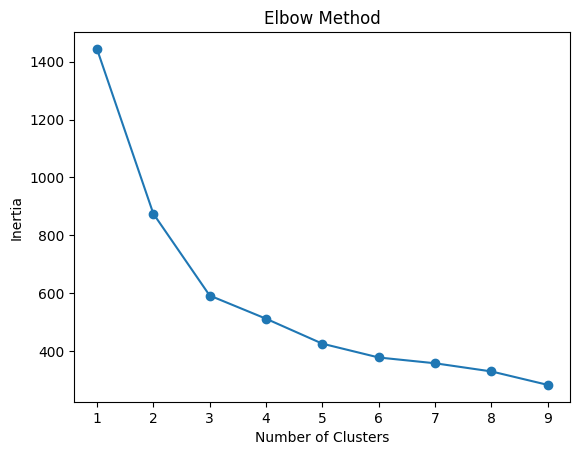

In [73]:
inertia = []
K_range = range(1,10)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_features)
    inertia.append(kmeans.inertia_)

plt.plot(K_range, inertia, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()



In [74]:
team_df.groupby("cluster")[["rating","kd","kd_diff"]].mean()

,rating,kd,kd_diff
cluster,,,
0,1.020709,1.048723,1093.652482
1,0.989887,0.968814,-546.310734
2,1.024186,1.055814,5040.255814


In [75]:
pca = PCA(n_components=2)

pca_features = pca.fit_transform(scaled_features)

pca_df = pd.DataFrame(
    pca_features,
    columns=["PC1","PC2"]
)

pca_df["cluster"] = team_df["cluster"]
pca_df["team"] = team_df["team"]

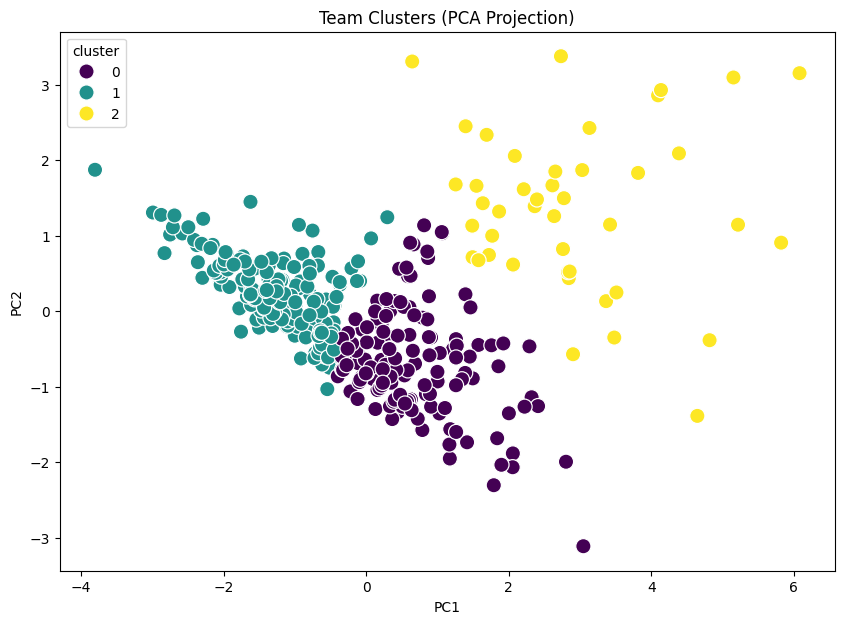

In [76]:
plt.figure(figsize=(10,7))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="cluster",
    palette="viridis",
    s=120
)

plt.title("Team Clusters (PCA Projection)")
plt.show()

In [77]:
best_players = player_df.sort_values("rating", ascending=False)

best_per_team = best_players.groupby("teams").first().reset_index()

best_per_team.head()

,teams,player,rating,kd,kd_diff
0,"[""Bee's Money Crew"", 'Ghost', 'J Money Crew']",bee,0.96,0.98,-73
1,"[""Ben's Anime Team"", 'Chaos', 'blitz']",wippie,1.11,1.19,359
2,"[""Let's Quit"", 'TYLOO']",qz,0.96,0.97,-63
3,"[""Save's"", ""Save's"", 'DreamEaters', 'Warthox',...",JACKPOT,0.89,0.88,-220
4,"[""Save's"", ""Save's"", 'Sherifi', 'RAVE']",bodyaN,0.96,0.97,-61


In [78]:
top_teams = team_df.sort_values("strength", ascending=False).head(5)

leaderboard = top_teams.merge(
    best_per_team,
    left_on="team",
    right_on="teams",
    how="left"
)

leaderboard[['team','strength','player','rating_y']]

,team,strength,player,rating_y
0,NIP,2349.841,NaN,NaN
1,TYLOO,2228.263,NaN,NaN
2,Astralis,2105.253,NaN,NaN
3,Natus Vincere,2087.031,NaN,NaN
4,ORDER,1758.070,NaN,NaN


In [79]:
matches = []

for cluster in team_df["cluster"].unique():
    
    teams = team_df[team_df["cluster"] == cluster]["team"].tolist()

    for i in range(0, len(teams)-1, 2):
        matches.append((teams[i], teams[i+1]))

print("Suggested Matches:")
for m in matches:
    print(m[0], "vs", m[1])

Suggested Matches:
Grayhound vs TYLOO
ViCi vs Renegades
ORDER vs Space Soldiers
NIP vs Astralis
HellRaisers vs G2
FURIA vs FaZe
Liquid vs Valiance
mousesports vs Dignitas
BIG vs Luminosity
Kinguin vs SK
Chiefs vs TeamOne
Sprout vs fnatic
HAVU vs Heroic
Cloud9 vs Natus Vincere
forZe vs OpTic
Complexity vs Envy
Virtus.pro vs Epsilon
AVANGAR vs AGO
NRG vs Spirit
LDLC vs Nemiga
Gambit vs Tricked
Recca vs Kings
Flash vs DarkPassage
Sinners vs MIBR
Dignitas fe vs Gambit Youngsters
CLG Red vs BOOM
Tainted Minds vs Extra Salt
Vitality vs ATK
MVP Project vs GOSU
100 Thieves vs OG
iNation vs 5POWER
c0ntact vs TIGER
CR4ZY vs MVP PK
Galaxy Racer vs Clan-Mystik
North vs OneThree
BOOT-d[S] vs VeryGames
Immunity vs TSM
Windigo vs Fiend
GoodJob vs eXtatus
Bren vs Secret Club
Paquetá vs Titan
Entropiq vs Immortals
Red Reserve vs Evil Geniuses
Trident vs Sharks
TNC vs Imperial
Gen.G vs Bad News Bears
CyberZen vs Outlaws
MVP.karnal vs Misfits
Tempo Storm vs Rise Nation
fnatic vs Swole Patrol
INTZ vs Ecli